In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


# Michael's method

Processing through tlist: 100%|██████████| 450/450 [00:01<00:00, 318.40it/s]


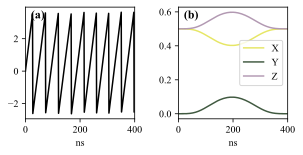

In [18]:
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*0.6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.4)





all_results = []
for i in range(5):
    with open(f'pickles/mcsolve_2.65_g0.13_a0.003_10level_qbt_state{i}_summed_two_level.pkl', 'rb') as file:
        result = pickle.load(file)
    all_results.append(result)
results = [all_results[1],all_results[2],all_results[3],all_results[4]]

with open(f'pickles/mcsolve_2.65_g0.13_a0.003_kappa_1e-3_phase.pkl','rb') as file:
    phases = pickle.load(file)


ax = plt.subplot(gs[0,0])
plt.text(0.05, 0.97, '(a)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')
plt.plot(results[0].times,phases,label = 'X',color = 'black')
plt.xlabel("ns")
ax.set_xlim((0,400))



zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)

states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
errors = {
    'X': [],
    'Y': [],
    'Z': []
}
inner_product_vals_dict = {
    'X': [],
    'Y': [],
    'Z': []
}

Paulis = [qutip.sigmax(),qutip.sigmay(),qutip.sigmaz()]
    
colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]

for idx in tqdm(range(len(results[0].times)), desc='Processing through tlist'):
    dms = [results[0].states[idx],
            results[1].states[idx],
            results[2].states[idx],
            results[3].states[idx]]
    gate = qutip.qip.operations.phasegate(theta=phases[idx])
    for P, Pauli in zip(['X','Y','Z'],Paulis):
        inner_product_vals = []
        for state_ideal, dm in zip(
            states_ideal,
            [dms[0],dms[1],dms[2],dms[3]]
            ):
            the_second_term = Pauli * qutip.ket2dm(state_ideal) * Pauli.dag()                    
            dm = gate * dm * gate.dag()
            inner_product = (the_second_term * dm).tr()
            inner_product_vals.append(inner_product)
        errors[P].append(sum(inner_product_vals)/len(inner_product_vals))
        inner_product_vals_dict[P].append(inner_product_vals)

ax = plt.subplot(gs[0,1])
plt.text(0.05, 0.97, '(b)', transform=plt.gca().transAxes, fontsize=12, fontweight='bold', va='top', color='black')

plt.plot(results[0].times,errors['X'],label = 'X',color = colors[0])
plt.plot(results[0].times,errors['Y'],label = 'Y',color = colors[1])
plt.plot(results[0].times,errors['Z'],label = 'Z',color = colors[2])
plt.xlabel("ns")
plt.legend()
ax.set_xlim((0,400))

plt.savefig('fig06_corrective_phase_and_pauli_error.pdf', format='pdf', bbox_inches='tight')


In [107]:
inner_product_vals_dict['Z'][400]

[0.999995275118371,
 0.9999986318776708,
 4.532615598659695e-05,
 4.572798540602996e-05]

In [102]:
i = 3
gate = qutip.qip.operations.phasegate(theta=phases[400])

first_term = gate * results[i].states[400] * gate.dag()

first_term

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.50003035+0.00000000e+00j -0.49995238-3.99579352e-06j]
 [-0.49995238+3.99579352e-06j  0.49996587+0.00000000e+00j]]

In [103]:
qutip.ket2dm(states_ideal[i])

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.5 -0.5]
 [-0.5  0.5]]

In [104]:
Pauli = qutip.sigmax()
the_second_term = Pauli * qutip.ket2dm(state_ideal) * Pauli.dag()  
the_second_term                

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
Qobj data =
[[ 0.5 -0.5]
 [-0.5  0.5]]

In [105]:
first_term * the_second_term

Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = False
Qobj data =
[[ 0.49999137+1.99789676e-06j -0.49999137-1.99789676e-06j]
 [-0.49995913+1.99789676e-06j  0.49995913-1.99789676e-06j]]

In [106]:
(first_term * the_second_term).tr()

0.9999504966874417